In [1]:
import torch
from matplotlib import pyplot as plt
from whar_datasets.adapters.pytorch import PytorchAdapter
from whar_datasets.support.getter import WHARDatasetID, get_whar_cfg
from flow_matching.latent.training_vae_cond import CondVAETrainer
from flow_matching.whar.stft import istft_transform, plot_spectrogram_grid
from flow_matching.whar.models.vae_cond import CondSpectrogramVAE
from flow_matching.whar.stft import decompress_stft

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
cfg = get_whar_cfg(WHARDatasetID.UCI_HAR)
cfg.subj_cross_val_split_groups
dataset = PytorchAdapter(cfg)

train_loader, val_loader, test_loader = dataset.get_dataloaders(
    train_batch_size=32, scv_group_index=0
)

num_classes = len(dataset.get_class_weights(train_loader))

Creating config hash...
Checking download...
Download exists.
Checking sessions...
Sessions exist.
Validating common format...
[########################################] | 100% Completed | 747.02 ms
Common format validated.
Checking windowing...
Loading config hash...
Windowing exists.
subject_ids: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]
activity_ids: [0 1 2 3 4 5]
train: 7201 | val: 801 | test: 1497
Postprocessing...


Loading windows: 100%|██████████| 9499/9499 [00:07<00:00, 1245.17it/s]


Getting normalization parameters...
Loading config hash...
Creating normalization parameters hash...
Loading normalization parameters hash...


Loading samples: 100%|██████████| 9499/9499 [00:02<00:00, 4485.29it/s]


In [4]:
latent_channels = 24

vae = CondSpectrogramVAE(latent_channels=latent_channels)

trainer = CondVAETrainer(
    model=vae,
    train_loader=train_loader,
    val_loader=val_loader,
    eta=(1 / num_classes),
    null_class=num_classes,
    track=True,
)

In [5]:
trainer.train(num_epochs=30, device=device, lr=1e-3, beta=0)

Training model with size: 8.005 MiB


  0%|          | 0/1 [00:00<?, ?it/s]/Users/maxburzer/flow-matching/src/flow_matching/whar/stft.py:33: UserWarning: There is a performance drop because we have not yet implemented the batching rule for aten::istft. Please file us an issue on GitHub so that we can prioritize its implementation. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/functorch/BatchedFallback.cpp:84.)
  waveform = torch.istft(
100%|██████████| 1/1 [00:01<00:00,  1.26s/it]


Loss: 0.023, MSE: 0.023, Log Mag: 1.863, Log Mag Phase: 2.844, Spect Conv: 0.718, Time MSE: 292.567, Time MAE: 10124.345


100%|██████████| 1/1 [00:00<00:00,  1.02it/s]


Loss: 0.022, MSE: 0.022, Log Mag: 1.995, Log Mag Phase: 2.975, Spect Conv: 0.698, Time MSE: 282.679, Time MAE: 9758.690


...

Loss: 0.022, MSE: 0.021, Log Mag: 2.560, Log Mag Phase: 3.538, Spect Conv: 0.677, Time MSE: 271.566, Time MAE: 9375.524


100%|██████████| 1/1 [00:01<00:00,  1.18s/it]


Loss: 0.022, MSE: 0.021, Log Mag: 2.591, Log Mag Phase: 3.569, Spect Conv: 0.681, Time MSE: 272.926, Time MAE: 9437.999


Epoch 11, Loss: 0.020:   9%|▉         | 21/226 [00:02<00:21,  9.45it/s]


KeyboardInterrupt: 

In [ ]:
torch.save(vae.state_dict(), f"models/cond_vae_{latent_channels}.pt")

In [ ]:
vae.load_state_dict(torch.load(f"models/cond_vae_{latent_channels}.pt"))

<All keys matched successfully>

tensor(-1.7221, device='mps:0', grad_fn=<MinBackward1>) tensor(1.9897, device='mps:0', grad_fn=<MaxBackward1>)
tensor(-0.9387) tensor(0.8518)
tensor(-0.9369) tensor(0.8674)


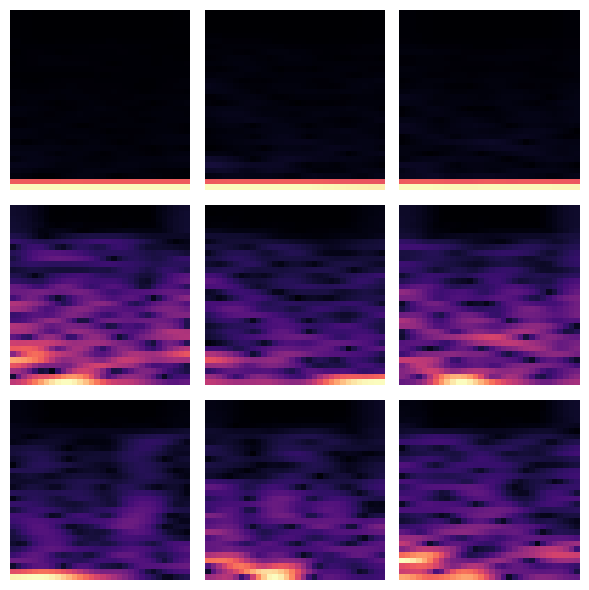

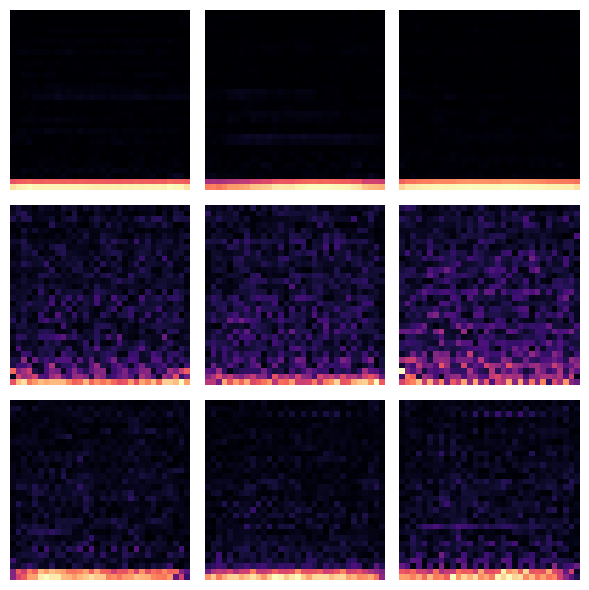

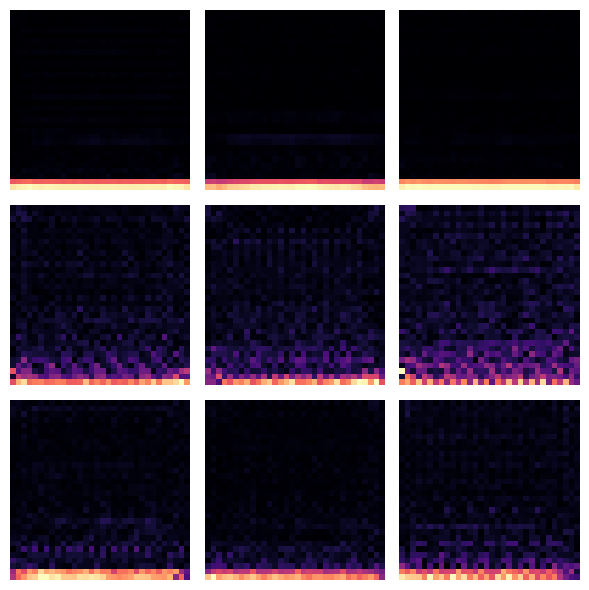

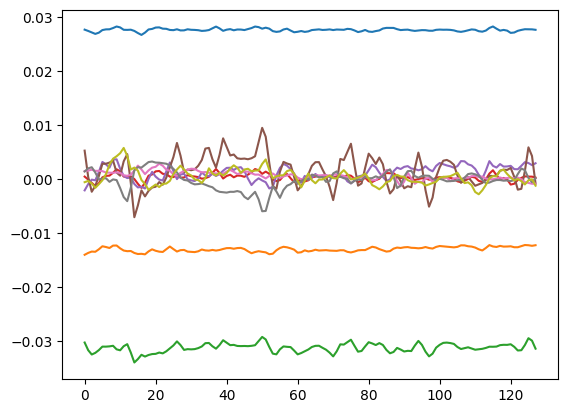

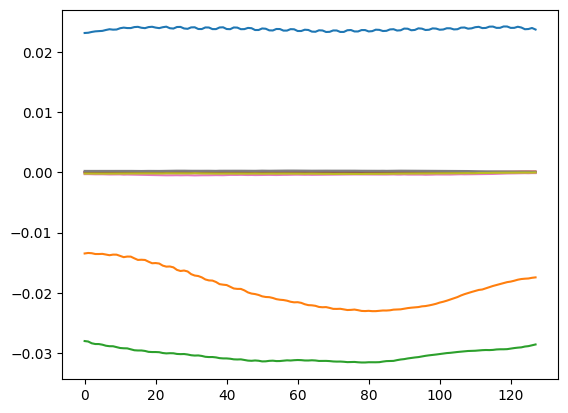

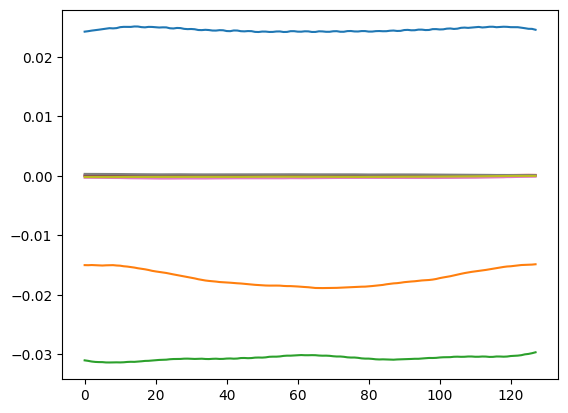

In [7]:
x, y = next(iter(train_loader))
# out, mu, logvar = vae(x.to(device), y.to(device))

z, mu, logvar = vae.encode(x.to(device), y.to(device))
out1 = vae.decode(z, y.to(device))
out2 = vae.decode(mu, y.to(device))

print(mu.min(), mu.max())

B, C, H, W = out1.shape
out1 = out1.reshape(B, C // 2, 2, H, W)[0].detach().cpu()
out2 = out2.reshape(B, C // 2, 2, H, W)[0].detach().cpu()

print(out1.min(), out1.max())
print(out2.min(), out2.max())

plot_spectrogram_grid(x.reshape(B, C // 2, 2, H, W)[0])
plot_spectrogram_grid(out1)
plot_spectrogram_grid(out2)


recon = istft_transform(decompress_stft(x.reshape(B, C // 2, 2, H, W)[0]))
plt.plot(recon)
plt.show()

recon = istft_transform(decompress_stft(out1))
plt.plot(recon)
plt.show()

recon = istft_transform(decompress_stft(out2))
plt.plot(recon)
plt.show()
